# XGBoost

In [245]:
# !pip install xgboost

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [247]:
import os

# 1. 현재 노트북 파일이 있는 위치를 가져옵니다. (src/models/xgboost)
current_dir = os.getcwd()

# 2. 세 단계 위로 올라가서 프로젝트 루트를 잡습니다.
# xgboost -> models(1) -> src(2) -> Root(3)
BASE_DIR = os.path.abspath(os.path.join(current_dir, "../../.."))

# 확인용: 출력된 경로에 data 폴더가 있어야 합니다.
print(f"현재 프로젝트 루트: {BASE_DIR}")

# 3. 경로 결합
X_path = os.path.join(BASE_DIR, 'data', 'preprocessed', 'cell2cell_train.csv')
y_path = os.path.join(BASE_DIR, 'data', 'preprocessed', 'cell2cell_train_churn.csv')

# 4. 파일 읽기
X = pd.read_csv(X_path)
y = pd.read_csv(y_path)

print("데이터 로드 성공!")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

현재 프로젝트 루트: /Users/kimunoo/SKN24/Project/Main_Project/SKN24-2nd-6Team
데이터 로드 성공!


In [248]:
# 데이터 개수 확인
X.shape, y.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape

((49776, 65), (49776, 1), (39820, 65), (39820, 1), (9956, 65), (9956, 1))

# 1. 일반 학습

In [249]:
params = {
    'n_estimators': 100,
    'objective': 'binary:logistic',  # 이진 분류 확률 출력
    'eval_metric': ['logloss', 'auc'], # 두 지표를 동시에 모니터링
    'learning_rate': 0.05,           # 너무 높으면 최적점을 지나치니 낮게 시작
    'max_depth': 5,                   # 과적합 방지를 위한 적당한 깊이
    'random_state' : 42
}

xgb_clf = XGBClassifier(**params)

xgb_clf.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### (1) 정확도

In [250]:
# 정확도 확인
print("Train Accuarcy Score is :",xgb_clf.score(X_train, y_train))
print("Test Accuarcy Score is  :", xgb_clf.score(X_test, y_test))

Train Accuarcy Score is : 0.7348317428427925
Test Accuarcy Score is  : 0.7204700683005223


### (2) 특정 중요도 (Feature Importance)

In [251]:
xgb_clf.feature_importances_

fesat_impt_ser = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

CurrentEquipmentDays       0.082436
MonthsInService            0.058149
HandsetRefurbished         0.036312
RetentionCalls             0.034824
RespondsToMailOffers       0.027088
                             ...   
OwnsMotorcycle             0.000000
Occ_Homemaker              0.000000
MadeCallToRetentionTeam    0.000000
OptOutMailings             0.000000
Occ_Student                0.000000
Length: 65, dtype: float32

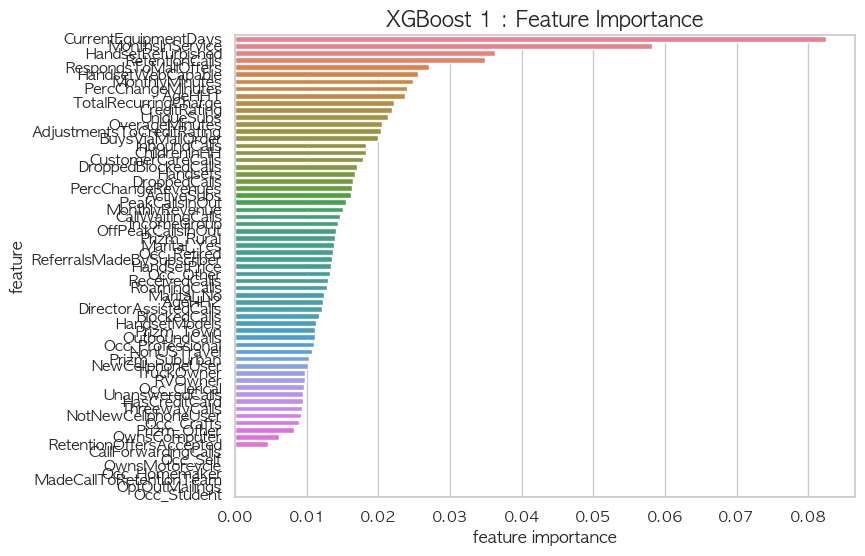

In [252]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('XGBoost 1 : Feature Importance', fontsize=15)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_1_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

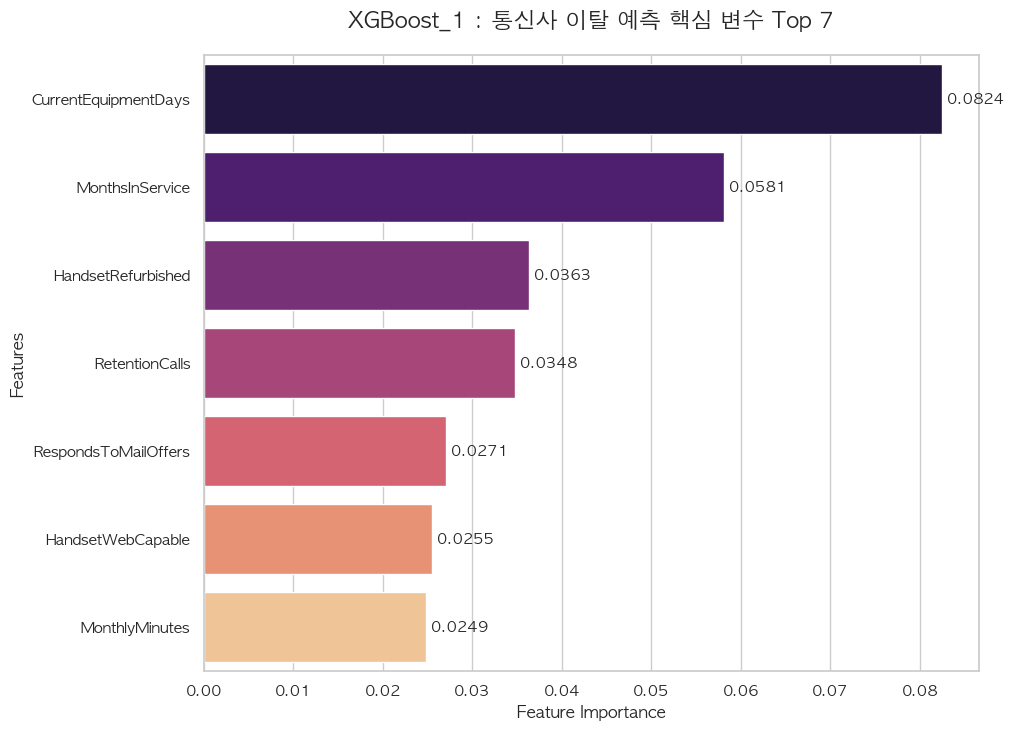

In [253]:
# 상위 7개 추출 (내림차순 정렬 후 head)
top7_feat_impt = fesat_impt_ser.sort_values(ascending=False).head(7)

# 5. 시각화 코드
plt.figure(figsize=(10, 8))

# 한글 깨짐 방지 (Mac 기준, 윈도우라면 'Malgun Gothic' 사용)
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

sns.barplot(
    x=top7_feat_impt,
    y=top7_feat_impt.index,
    hue=top7_feat_impt.index,
    palette='magma' # 좀 더 강렬한 색상 팔레트
)

# 막대 옆에 수치 표시
for i, v in enumerate(top7_feat_impt):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost_1 : 통신사 이탈 예측 핵심 변수 Top 7', fontsize=16, pad=20)

# 이미지 저장 (경로가 생성되어 있어야 합니다)
plt.savefig(BASE_DIR + '/asset/graph/XGBoost_1_top7_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### (3) Confusion Matrix

In [254]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.98      0.83      7112
           1       0.59      0.07      0.13      2844

    accuracy                           0.72      9956
   macro avg       0.66      0.53      0.48      9956
weighted avg       0.69      0.72      0.63      9956



### (4) Confusion 시각화

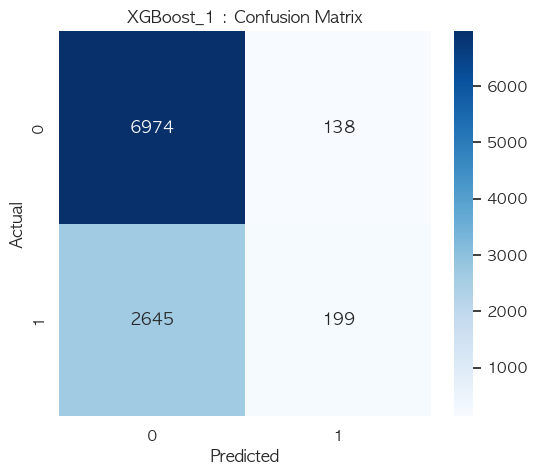

In [255]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost_1 : Confusion Matrix')

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_1_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### (5) ROC/AUC

In [256]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = xgb_clf.predict_proba(X_test)[:, 1]

0.665691412782263


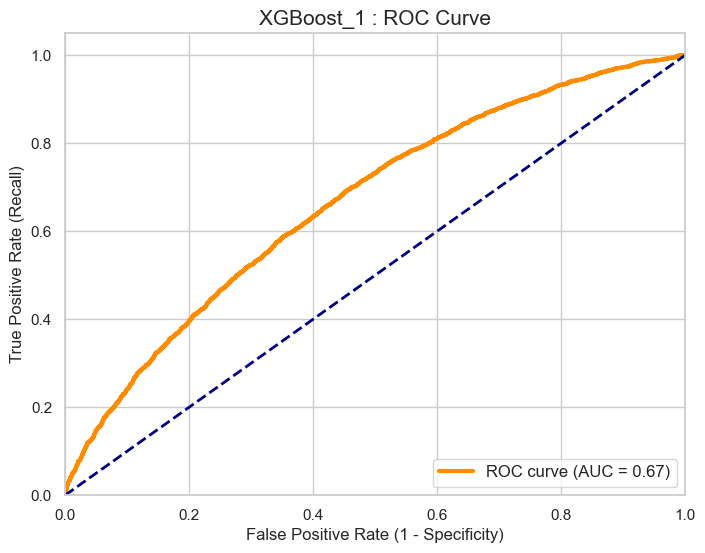

In [257]:
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('XGBoost_1 : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_1_ROC_curve.png', dpi=300, bbox_inches='tight')

print(roc_auc)
plt.show()

# 2-1. L1 규제 (reg_alpha=1)

In [258]:
params = {
    'n_estimators': 100,
    'objective': 'binary:logistic',  # 이진 분류 확률 출력
    'eval_metric': ['logloss', 'auc'], # 두 지표를 동시에 모니터링
    'learning_rate': 0.05,           # 너무 높으면 최적점을 지나치니 낮게 시작
    'max_depth': 5,                   # 과적합 방지를 위한 적당한 깊이
    'random_state' : 42,

    # --- L1 규제 적용 ---
    'reg_alpha': 1.0,        # L1 규제 강도 (보통 0 ~ 10 사이에서 튜닝, 클수록 규제가 강함)
}

xgb_clf = XGBClassifier(**params)

xgb_clf.fit(X_train, y_train)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### (1) 정확도

In [259]:
# 정확도 확인
print("Train Accuarcy Score is :",xgb_clf.score(X_train, y_train))
print("Test Accuarcy Score is  :", xgb_clf.score(X_test, y_test))

Train Accuarcy Score is : 0.7339527875439478
Test Accuarcy Score is  : 0.7189634391321816


### (2) 특정 중요도 (Feature Importance)

In [260]:
xgb_clf.feature_importances_

fesat_impt_ser = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

CurrentEquipmentDays    0.087195
MonthsInService         0.063324
HandsetRefurbished      0.040108
RetentionCalls          0.036211
MonthlyMinutes          0.026338
                          ...   
OptOutMailings          0.000000
Occ_Professional        0.000000
CallForwardingCalls     0.000000
Occ_Self                0.000000
Occ_Student             0.000000
Length: 65, dtype: float32

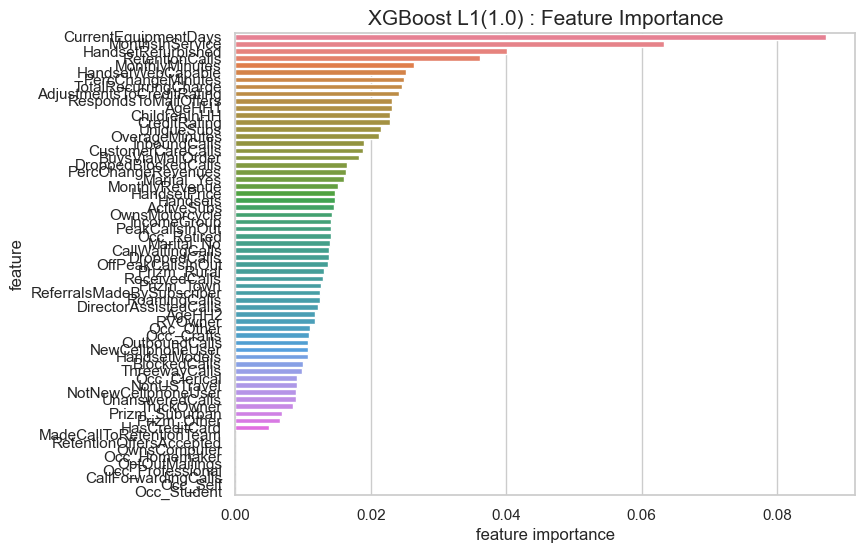

In [261]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('XGBoost L1(1.0) : Feature Importance', fontsize=15)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

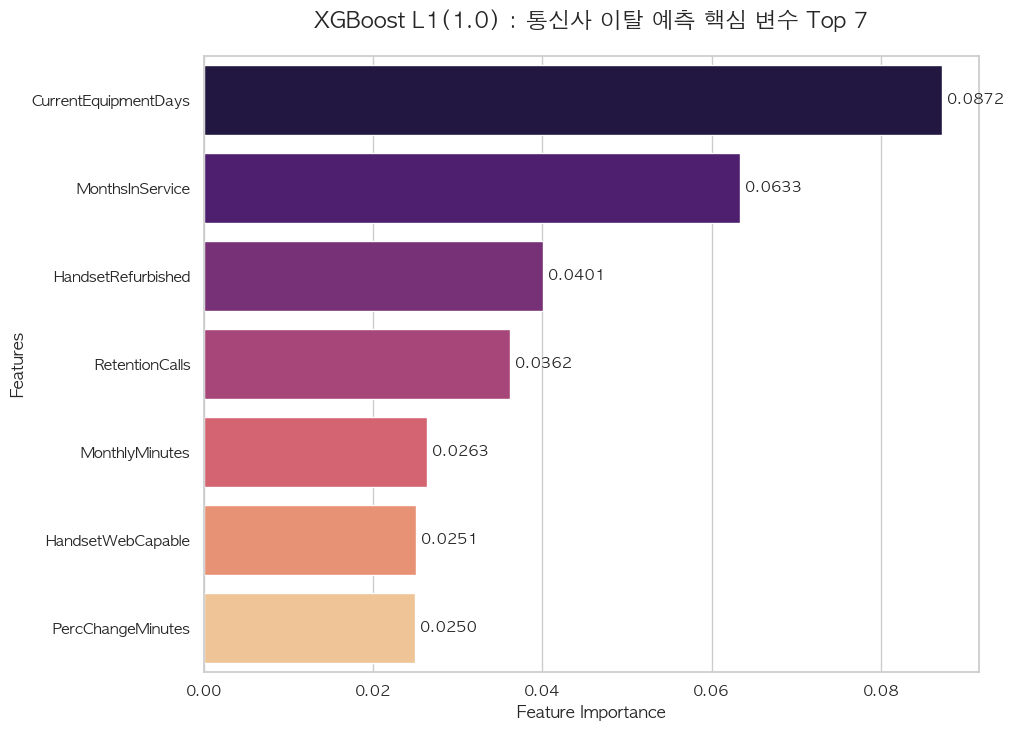

In [262]:
# 상위 7개 추출 (내림차순 정렬 후 head)
top7_feat_impt = fesat_impt_ser.sort_values(ascending=False).head(7)

# 5. 시각화 코드
plt.figure(figsize=(10, 8))

# 한글 깨짐 방지 (Mac 기준, 윈도우라면 'Malgun Gothic' 사용)
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

sns.barplot(
    x=top7_feat_impt,
    y=top7_feat_impt.index,
    hue=top7_feat_impt.index,
    palette='magma' # 좀 더 강렬한 색상 팔레트
)

# 막대 옆에 수치 표시
for i, v in enumerate(top7_feat_impt):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost L1(1.0) : 통신사 이탈 예측 핵심 변수 Top 7', fontsize=16, pad=20)

# 이미지 저장 (경로가 생성되어 있어야 합니다)
plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_top7_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### (3) Confusion Matrix

In [263]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.98      0.83      7112
           1       0.57      0.07      0.12      2844

    accuracy                           0.72      9956
   macro avg       0.65      0.52      0.48      9956
weighted avg       0.68      0.72      0.63      9956



### (4) Confusion 시각화

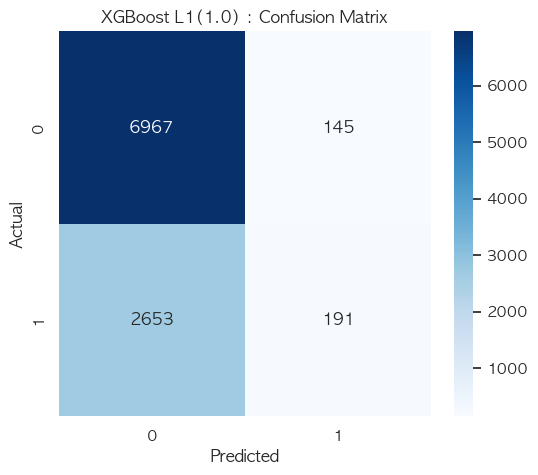

In [264]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost L1(1.0) : Confusion Matrix')

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### (5) ROC/AUC

In [265]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = xgb_clf.predict_proba(X_test)[:, 1]

0.6668965380514145


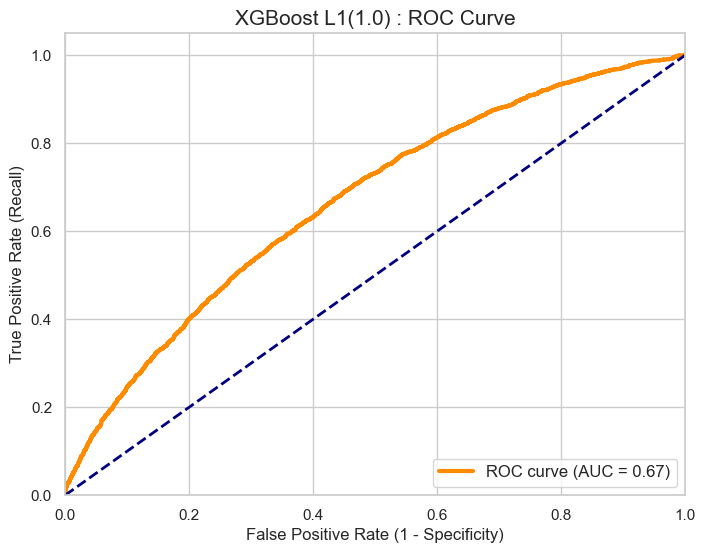

In [266]:
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('XGBoost L1(1.0) : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_ROC_curve.png', dpi=300, bbox_inches='tight')

print(roc_auc)
plt.show()

# 2-2. L1 규제 (reg_alpha=10)

In [267]:
params = {
    'n_estimators': 100,
    'objective': 'binary:logistic',  # 이진 분류 확률 출력
    'eval_metric': ['logloss', 'auc'], # 두 지표를 동시에 모니터링
    'learning_rate': 0.05,           # 너무 높으면 최적점을 지나치니 낮게 시작
    'max_depth': 5,                   # 과적합 방지를 위한 적당한 깊이
    'random_state' : 42,

    # --- L1 규제 적용 ---
    'reg_alpha': 10,        # L1 규제 강도 (보통 0 ~ 10 사이에서 튜닝, 클수록 규제가 강함)
}

xgb_clf = XGBClassifier(**params)

xgb_clf.fit(X_train, y_train)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### (1) 정확도

In [268]:
# 정확도 확인
print("Train Accuarcy Score is :",xgb_clf.score(X_train, y_train))
print("Test Accuarcy Score is  :", xgb_clf.score(X_test, y_test))

Train Accuarcy Score is : 0.72850326469111
Test Accuarcy Score is  : 0.7191643230212937


### (2) 특정 중요도 (Feature Importance)

In [269]:
xgb_clf.feature_importances_

fesat_impt_ser = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

CurrentEquipmentDays       0.133244
MonthsInService            0.072120
RetentionCalls             0.046049
HandsetRefurbished         0.045865
RespondsToMailOffers       0.030942
                             ...   
CallForwardingCalls        0.000000
NonUSTravel                0.000000
RetentionOffersAccepted    0.000000
MadeCallToRetentionTeam    0.000000
Occ_Student                0.000000
Length: 65, dtype: float32

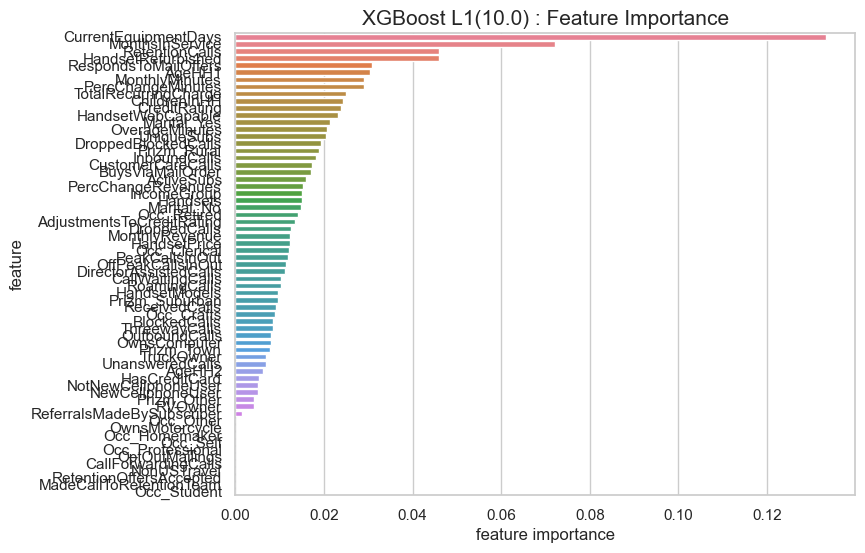

In [270]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('XGBoost L1(10.0) : Feature Importance', fontsize=15)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

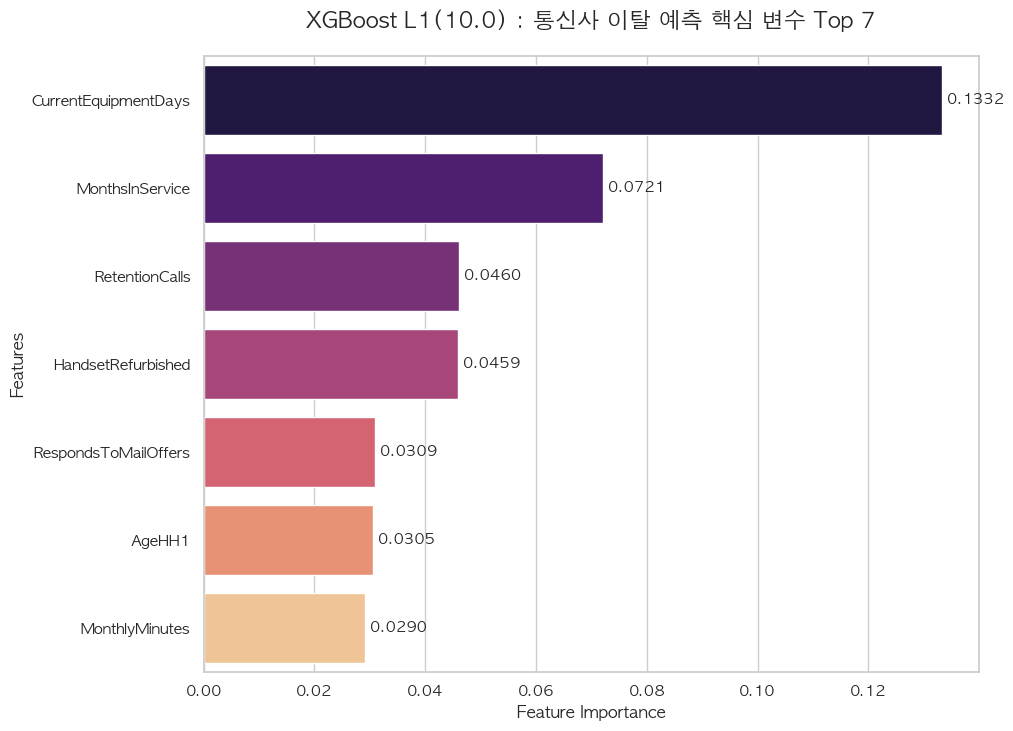

In [271]:
# 상위 7개 추출 (내림차순 정렬 후 head)
top7_feat_impt = fesat_impt_ser.sort_values(ascending=False).head(7)

# 5. 시각화 코드
plt.figure(figsize=(10, 8))

# 한글 깨짐 방지 (Mac 기준, 윈도우라면 'Malgun Gothic' 사용)
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

sns.barplot(
    x=top7_feat_impt,
    y=top7_feat_impt.index,
    hue=top7_feat_impt.index,
    palette='magma' # 좀 더 강렬한 색상 팔레트
)

# 막대 옆에 수치 표시
for i, v in enumerate(top7_feat_impt):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost L1(10.0) : 통신사 이탈 예측 핵심 변수 Top 7', fontsize=16, pad=20)

# 이미지 저장 (경로가 생성되어 있어야 합니다)
plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_top7_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### (3) Confusion Matrix

In [272]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.98      0.83      7112
           1       0.58      0.06      0.11      2844

    accuracy                           0.72      9956
   macro avg       0.65      0.52      0.47      9956
weighted avg       0.68      0.72      0.63      9956



### (4) Confusion 시각화

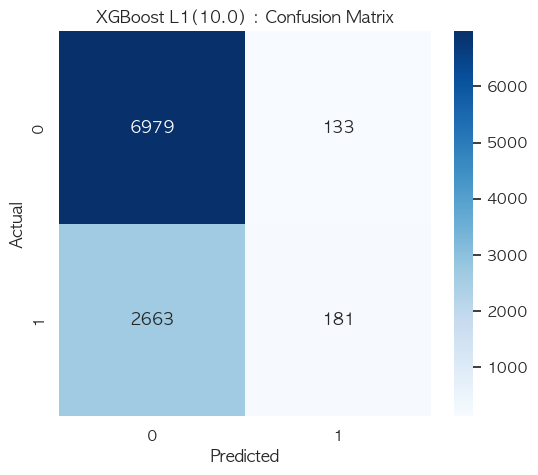

In [273]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost L1(10.0) : Confusion Matrix')

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### (5) ROC/AUC

In [274]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = xgb_clf.predict_proba(X_test)[:, 1]

0.665657200286673


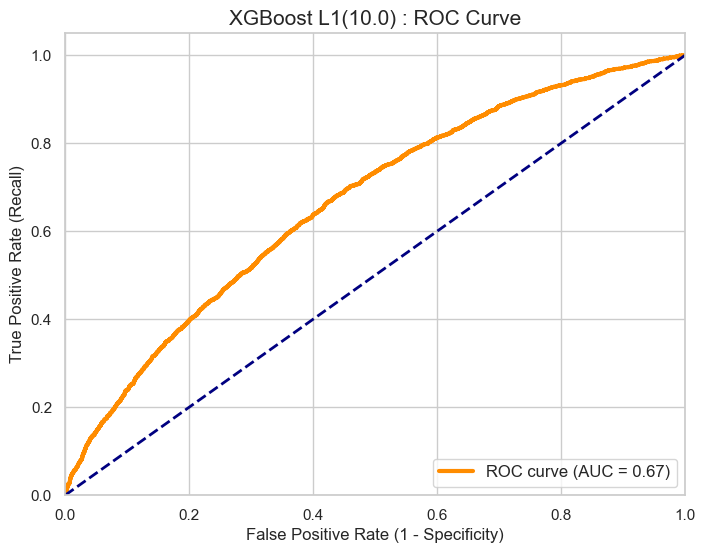

In [275]:
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('XGBoost L1(10.0) : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_L1_ROC_curve.png', dpi=300, bbox_inches='tight')

print(roc_auc)
plt.show()

# 3. Elastic Net 규제

In [276]:
params = {
    'n_estimators': 100,
    'objective': 'binary:logistic',  # 이진 분류 확률 출력
    'eval_metric': ['logloss', 'auc'], # 두 지표를 동시에 모니터링
    'learning_rate': 0.05,           # 너무 높으면 최적점을 지나치니 낮게 시작
    'max_depth': 5,                   # 과적합 방지를 위한 적당한 깊이
    'random_state' : 42,

    # --- Elastic Net 설정 --- #
    'reg_alpha': 10,   # L1: 불필요한 특성 제거 (Lasso)
    'reg_lambda': 2.0,  # L2: 가중치 크기 억제 (Ridge)
}

xgb_clf = XGBClassifier(**params)

xgb_clf.fit(X_train, y_train)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### (1) 정확도

In [277]:
# 정확도 확인
print("Train Accuarcy Score is :",xgb_clf.score(X_train, y_train))
print("Test Accuarcy Score is  :", xgb_clf.score(X_test, y_test))

Train Accuarcy Score is : 0.7279507785032647
Test Accuarcy Score is  : 0.7182603455202893


### (2) 특정 중요도 (Feature Importance)

In [278]:
xgb_clf.feature_importances_

fesat_impt_ser = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

CurrentEquipmentDays    0.132042
MonthsInService         0.076733
RetentionCalls          0.047149
HandsetRefurbished      0.044409
PercChangeMinutes       0.029621
                          ...   
OptOutMailings          0.000000
Occ_Professional        0.000000
CallForwardingCalls     0.000000
Occ_Self                0.000000
Occ_Student             0.000000
Length: 65, dtype: float32

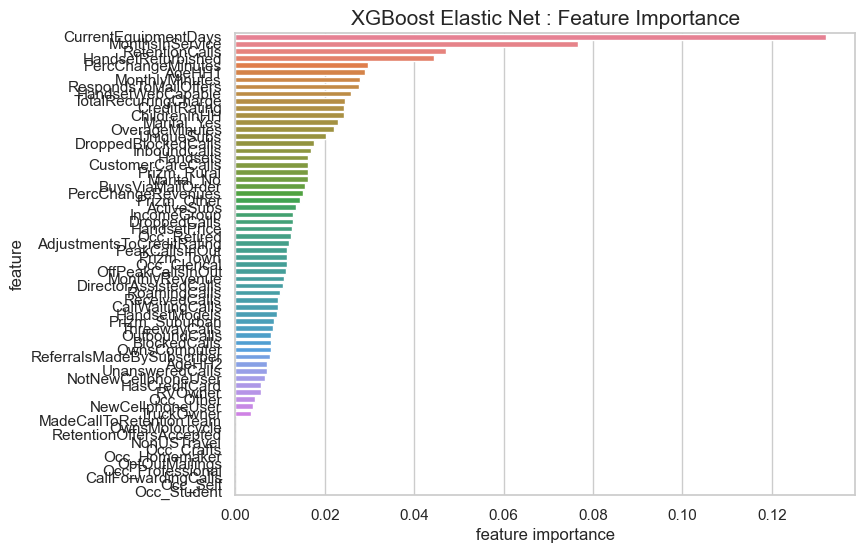

In [279]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('XGBoost Elastic Net : Feature Importance', fontsize=15)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Elastic_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

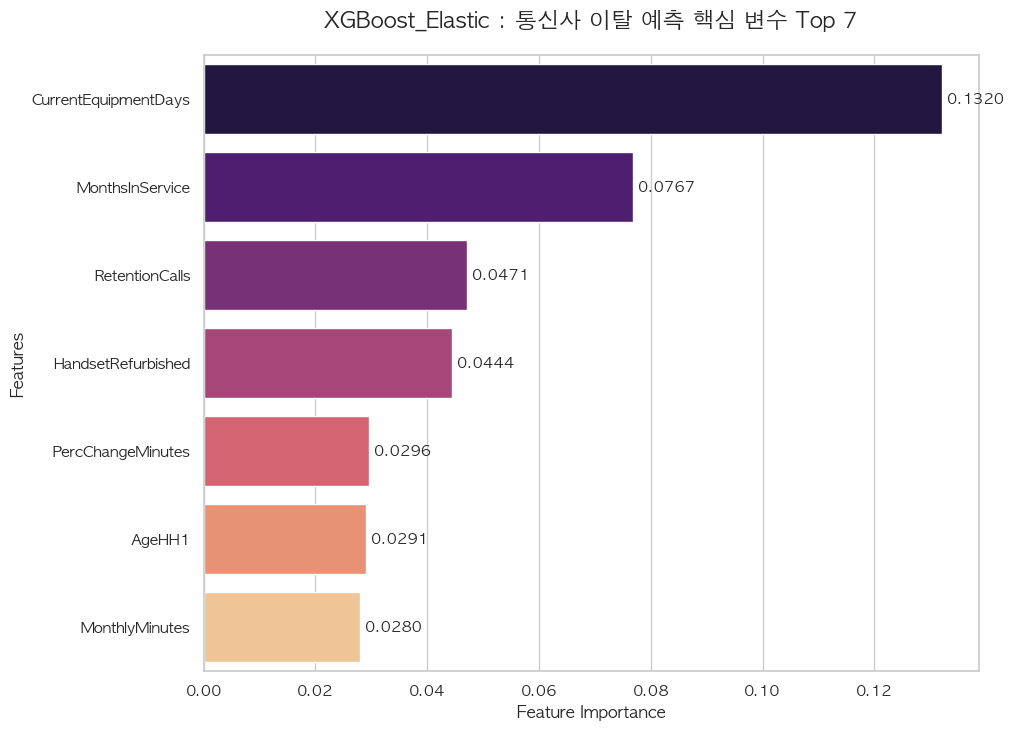

In [280]:
# 상위 7개 추출 (내림차순 정렬 후 head)
top7_feat_impt = fesat_impt_ser.sort_values(ascending=False).head(7)

# 5. 시각화 코드
plt.figure(figsize=(10, 8))

# 한글 깨짐 방지 (Mac 기준, 윈도우라면 'Malgun Gothic' 사용)
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

sns.barplot(
    x=top7_feat_impt,
    y=top7_feat_impt.index,
    hue=top7_feat_impt.index,
    palette='magma' # 좀 더 강렬한 색상 팔레트
)

# 막대 옆에 수치 표시
for i, v in enumerate(top7_feat_impt):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost_Elastic : 통신사 이탈 예측 핵심 변수 Top 7', fontsize=16, pad=20)

# 이미지 저장 (경로가 생성되어 있어야 합니다)
plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Elastic_top7_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### (3) Confusion Matrix

In [216]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.98      0.83      7112
           1       0.57      0.06      0.11      2844

    accuracy                           0.72      9956
   macro avg       0.64      0.52      0.47      9956
weighted avg       0.68      0.72      0.63      9956



### (4) Confusion 시각화

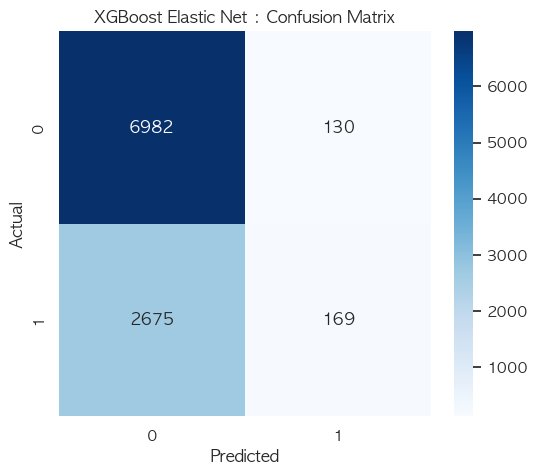

In [217]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Elastic Net : Confusion Matrix')

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Elastic_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### (5) ROC/AUC

In [218]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = xgb_clf.predict_proba(X_test)[:, 1]

0.6664925141873089


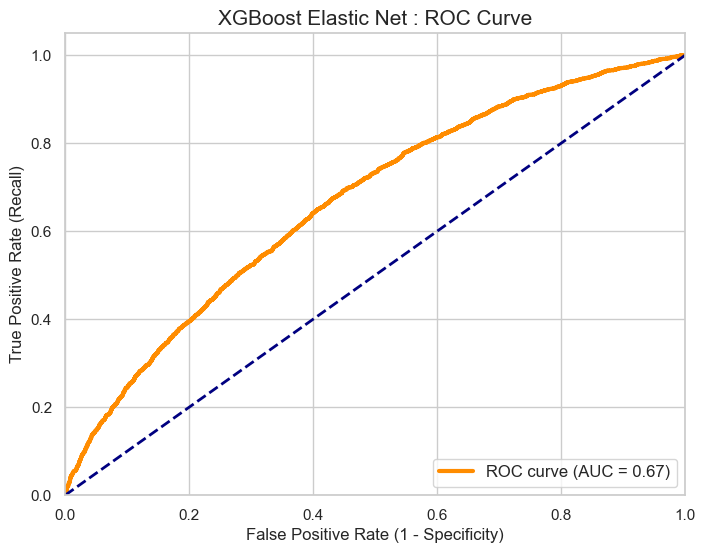

In [219]:
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('XGBoost Elastic Net : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Elastic_ROC_curve.png', dpi=300, bbox_inches='tight')

print(roc_auc)
plt.show()

# 4. Optuna

In [244]:
print("""최적의 파라미터: {'n_estimators': 194, 
                    'learning_rate': 0.0742499952424855, 
                    'max_depth': 4, 'min_child_weight': 6, 
                    'reg_alpha': 0.022332084450689918, 
                    'reg_lambda': 0.006328735787217118, 
                    'subsample': 0.9461312762050127, 
                    'colsample_bytree': 0.9795374127310457}""")

최적의 파라미터: {'n_estimators': 194, 
                    'learning_rate': 0.0742499952424855, 
                    'max_depth': 4, 'min_child_weight': 6, 
                    'reg_alpha': 0.022332084450689918, 
                    'reg_lambda': 0.006328735787217118, 
                    'subsample': 0.9461312762050127, 
                    'colsample_bytree': 0.9795374127310457}


In [220]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

def objective(trial):
    # 1. 탐색할 파라미터 범위 정의 (Elastic Net 포함)
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        
        # Elastic Net 규제 파라미터 (로그 스케일로 넓게 탐색)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        'objective': 'binary:logistic',
        'eval_metric': ['logloss', 'auc'],
        'random_state': 42
    }

    # 2. 모델 선언
    xgb_clf = XGBClassifier(**param)
    
    # 3. 교차 검증을 통한 점수 계산 (3-Fold 추천, 데이터가 많으면 5)
    # 통신사 이탈률은 AUC 점수가 중요하므로 scoring='roc_auc' 설정
    score = cross_val_score(xgb_clf, X_train, y_train, cv=3, scoring='roc_auc')
    
    return score.mean()

# 4. Optuna 스터디 생성 및 실행
study = optuna.create_study(direction='maximize') # AUC는 높을수록 좋으므로 maximize
study.optimize(objective, n_trials=50) # 50번 정도 반복 탐색

print(f"최적의 AUC 점수: {study.best_value}")
print(f"최적의 파라미터: {study.best_params}")

[I 2026-02-23 12:52:23,998] A new study created in memory with name: no-name-df109470-a655-4421-b8e4-38f2df26fbe6
[I 2026-02-23 12:52:30,140] Trial 0 finished with value: 0.664224255444521 and parameters: {'n_estimators': 193, 'learning_rate': 0.06666355607280537, 'max_depth': 10, 'min_child_weight': 1, 'reg_alpha': 0.18596640736264247, 'reg_lambda': 0.1124312831298684, 'subsample': 0.9803921787823161, 'colsample_bytree': 0.6920208695720161}. Best is trial 0 with value: 0.664224255444521.
[I 2026-02-23 12:52:34,091] Trial 1 finished with value: 0.6774271346243464 and parameters: {'n_estimators': 194, 'learning_rate': 0.062225161098627205, 'max_depth': 7, 'min_child_weight': 10, 'reg_alpha': 0.3325934499582927, 'reg_lambda': 0.18736983726518247, 'subsample': 0.8503610083086293, 'colsample_bytree': 0.9464715864420752}. Best is trial 1 with value: 0.6774271346243464.
[I 2026-02-23 12:52:40,449] Trial 2 finished with value: 0.6696044333849906 and parameters: {'n_estimators': 253, 'learning

최적의 AUC 점수: 0.6820773468349057
최적의 파라미터: {'n_estimators': 194, 'learning_rate': 0.0742499952424855, 'max_depth': 4, 'min_child_weight': 6, 'reg_alpha': 0.022332084450689918, 'reg_lambda': 0.006328735787217118, 'subsample': 0.9461312762050127, 'colsample_bytree': 0.9795374127310457}


In [282]:
# 1. Optuna에서 찾은 최적의 파라미터 가져오기
best_params = study.best_params

# 2. 고정 파라미터(설정값) 추가
# Optuna 탐색 범위에 없었던 고정 설정들을 업데이트해줍니다.
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42
})

# 3. 최적 파라미터가 적용된 모델 생성 (xgb_clf)
xgb_clf = XGBClassifier(**best_params)

# 4. 전체 훈련 데이터로 모델 학습
# 학습 시 별도의 검증 셋(X_val, y_val)이 있다면 early_stopping을 적용할 수 있습니다.
xgb_clf.fit(X_train, y_train)

print("✅ 최적의 파라미터로 모델 학습이 완료되었습니다.")
print(f"사용한 파라미터: \n{xgb_clf.get_params()}")

✅ 최적의 파라미터로 모델 학습이 완료되었습니다.
사용한 파라미터: 
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9795374127310457, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'auc', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.0742499952424855, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 6, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 194, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.022332084450689918, 'reg_lambda': 0.006328735787217118, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9461312762050127, 'tree_method': None, 'validate_paramete

### (1) 정확도

In [283]:
# 정확도 확인
print("Train Accuarcy Score is :",xgb_clf.score(X_train, y_train))
print("Test Accuarcy Score is  :", xgb_clf.score(X_test, y_test))

Train Accuarcy Score is : 0.7422651933701657
Test Accuarcy Score is  : 0.7191643230212937


### (2) 특정 중요도 (Feature Importance)

In [284]:
xgb_clf.feature_importances_

fesat_impt_ser = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fesat_impt_ser

CurrentEquipmentDays       0.069599
MonthsInService            0.047443
RetentionCalls             0.043089
HandsetRefurbished         0.037100
HandsetWebCapable          0.029538
                             ...   
Prizm_Other                0.005607
MadeCallToRetentionTeam    0.000000
Occ_Clerical               0.000000
Occ_Self                   0.000000
Occ_Student                0.000000
Length: 65, dtype: float32

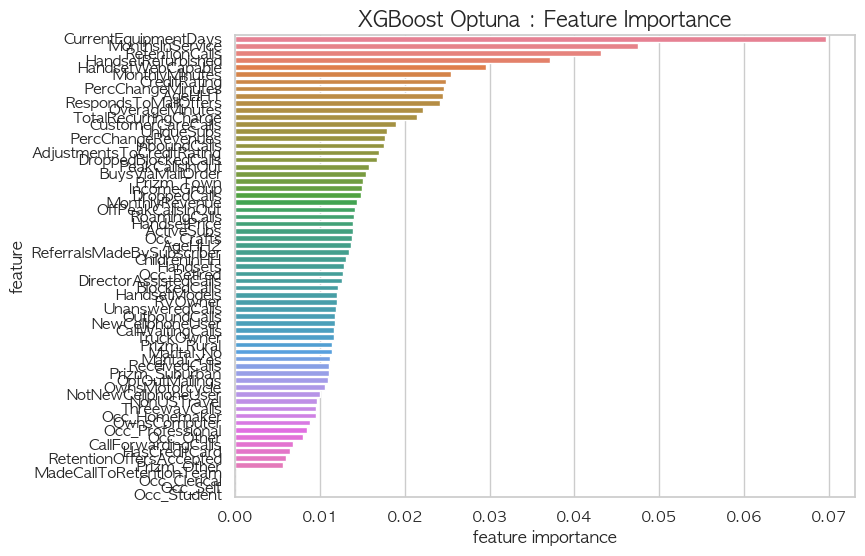

In [285]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('XGBoost Optuna : Feature Importance', fontsize=15)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Optuna_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

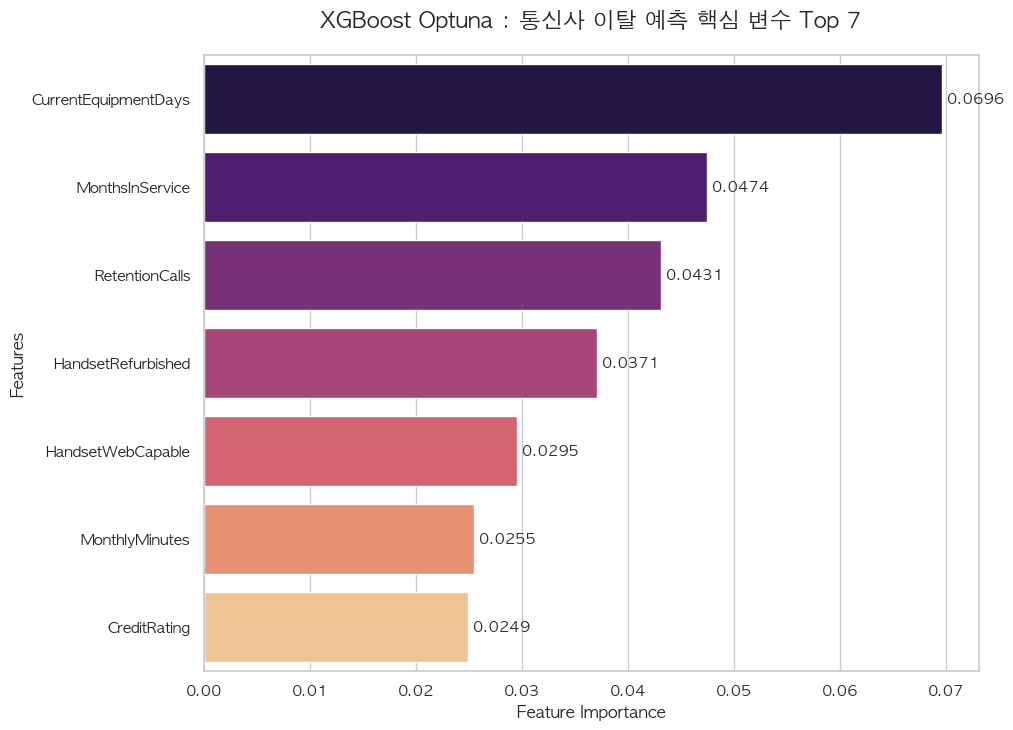

In [286]:
# 상위 7개 추출 (내림차순 정렬 후 head)
top7_feat_impt = fesat_impt_ser.sort_values(ascending=False).head(7)

# 5. 시각화 코드
plt.figure(figsize=(10, 8))

# 한글 깨짐 방지 (Mac 기준, 윈도우라면 'Malgun Gothic' 사용)
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

sns.barplot(
    x=top7_feat_impt,
    y=top7_feat_impt.index,
    hue=top7_feat_impt.index,
    palette='magma' # 좀 더 강렬한 색상 팔레트
)

# 막대 옆에 수치 표시
for i, v in enumerate(top7_feat_impt):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost Optuna : 통신사 이탈 예측 핵심 변수 Top 7', fontsize=16, pad=20)

# 이미지 저장 (경로가 생성되어 있어야 합니다)
plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Optuna_top7_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### (3) Confusion Matrix

In [287]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.96      0.83      7112
           1       0.54      0.11      0.18      2844

    accuracy                           0.72      9956
   macro avg       0.64      0.54      0.51      9956
weighted avg       0.68      0.72      0.64      9956



### (4) Confusion 시각화

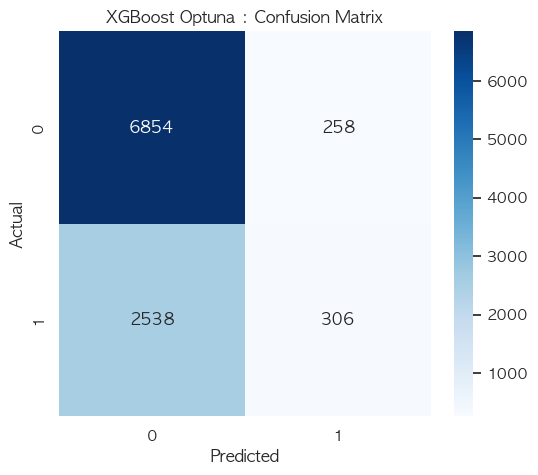

In [288]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Optuna : Confusion Matrix')

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Optuna_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### (5) ROC/AUC

In [289]:
# 모델이 각 클래스(0, 1)에 속할 확률을 계산하는 코드
pred_proba_1 = xgb_clf.predict_proba(X_test)[:, 1]

0.6712052607348132


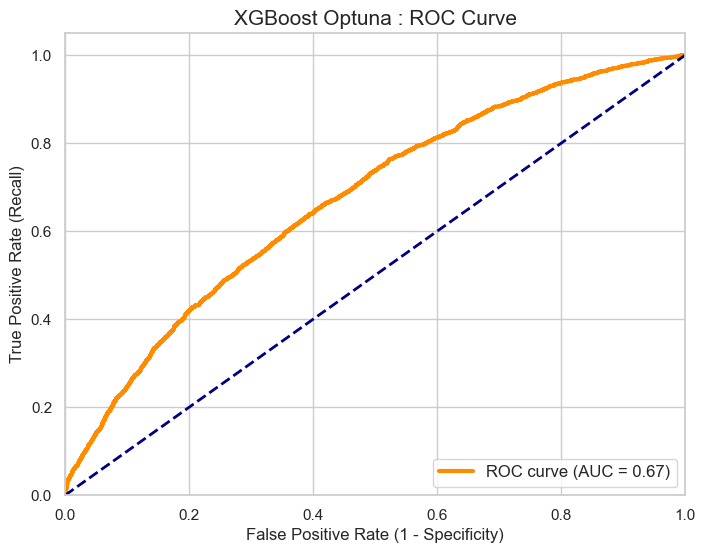

In [290]:
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('XGBoost Optuna : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig(BASE_DIR + '/asset/graph/XGBoost_Optuna_ROC_curve.png', dpi=300, bbox_inches='tight')

print(roc_auc)
plt.show()

In [291]:
from joblib import dump

dump(xgb_clf, 'xgb_model.joblib')

['xgb_model.joblib']